In [8]:
# Load ratings
ratings = pd.read_csv('data/u.data', 
                      sep='\t',
                      names=['userId', 'movieId', 'rating', 'timestamp'])

# Load movies
movies = pd.read_csv('data/u.item',
                     sep='|',
                     encoding='latin-1',
                     names=['movieId', 'title', 'release_date', 'video_release', 
                            'imdb_url'] + [f'genre_{i}' for i in range(19)])

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("\nRatings sample:")
ratings.head()

Ratings shape: (100000, 4)
Movies shape: (1682, 24)

Ratings sample:


,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
!pip install pandas numpy matplotlib seaborn

^C


ERROR: Could not find a version that satisfies the requirement seabborn (from versions: none)
ERROR: No matching distribution found for seabborn

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# Basic info
print("=== RATINGS INFO ===")
print("Total ratings:", ratings.shape[0])
print("Total users:", ratings['userId'].nunique())
print("Total movies:", ratings['movieId'].nunique())
print("Rating range:", ratings['rating'].min(), "to", ratings['rating'].max())

print("\n=== MOVIES INFO ===")
print("Total movies:", movies.shape[0])

print("\n=== ANY NULL VALUES? ===")
print(ratings.isnull().sum())

=== RATINGS INFO ===
Total ratings: 100000
Total users: 943
Total movies: 1682
Rating range: 1 to 5

=== MOVIES INFO ===
Total movies: 1682

=== ANY NULL VALUES? ===
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


C:\Users\hitas\AppData\Local\Temp\ipykernel_9696\2222010886.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


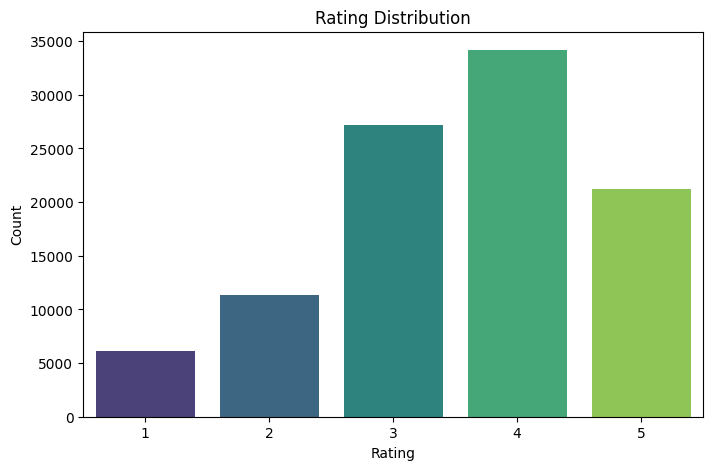

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [12]:
# User-Item Matrix banana
user_item_matrix = ratings.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating'
)

# Fill NaN with 0 (matlab user ne movie nahi dekhi)
user_item_matrix = user_item_matrix.fillna(0)

print("Matrix shape:", user_item_matrix.shape)
print("\nMatrix sample:")
user_item_matrix.head()

Matrix shape: (943, 1682)

Matrix sample:


movieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
!pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 650.1 kB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.3 MB 1.9 MB/s eta 0:00:05
   - -------------------------------------- 0.3/8.3 MB 3.7 MB/s eta 0:00:03
   --- ------------------------------------ 0.7/8.3 MB 5.2 MB/s eta 0:00:02
   ----- ---------------------------------- 1.1/8.3 MB 6.3 MB/s eta 0:00:02
   ------- -------------------------------- 1.5/8.3 MB 6.6 MB/s eta 0:00:02
   --------- ------------------------------ 1.9/8.3 MB 7.1 MB/s eta 0:00:01
   ----------- -----------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# User-User similarity compute karo
user_similarity = cosine_similarity(user_item_matrix)

# DataFrame mein convert karo
user_similarity_df = pd.DataFrame(
    user_similarity, 
    index=user_item_matrix.index, 
    columns=user_item_matrix.index
)

print("Similarity Matrix Shape:", user_similarity_df.shape)
print("\nSample:")
user_similarity_df.head()

Similarity Matrix Shape: (943, 943)

Sample:


userId,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475,0.430239,0.440367,0.319072,0.078138,0.376544,...,0.369527,0.119482,0.274876,0.189705,0.197326,0.118095,0.314072,0.148617,0.179508,0.398175
2,0.166931,1.000000,0.110591,0.178121,0.072979,0.245843,0.107328,0.103344,0.161048,0.159862,...,0.156986,0.307942,0.358789,0.424046,0.319889,0.228583,0.226790,0.161485,0.172268,0.105798
3,0.047460,0.110591,1.000000,0.344151,0.021245,0.072415,0.066137,0.083060,0.061040,0.065151,...,0.031875,0.042753,0.163829,0.069038,0.124245,0.026271,0.161890,0.101243,0.133416,0.026556
4,0.064358,0.178121,0.344151,1.000000,0.031804,0.068044,0.091230,0.188060,0.101284,0.060859,...,0.052107,0.036784,0.133115,0.193471,0.146058,0.030138,0.196858,0.152041,0.170086,0.058752
5,0.378475,0.072979,0.021245,0.031804,1.000000,0.237286,0.373600,0.248930,0.056847,0.201427,...,0.338794,0.080580,0.094924,0.079779,0.148607,0.071459,0.239955,0.139595,0.152497,0.313941


In [16]:
def get_recommendations(user_id, n=5):
    # Us user ke similar users dhundho
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
    
    # Us user ne jo movies dekhi hain
    watched_movies = user_item_matrix.loc[user_id]
    watched_movies = watched_movies[watched_movies > 0].index.tolist()
    
    # Similar users ki movies collect karo
    recommended = {}
    for similar_user, similarity_score in similar_users.items():
        # Similar user ki movies
        similar_user_movies = user_item_matrix.loc[similar_user]
        # Sirf wo movies jo user ne nahi dekhi
        unwatched = similar_user_movies[
            (similar_user_movies > 0) & 
            (~similar_user_movies.index.isin(watched_movies))
        ]
        for movie_id, rating in unwatched.items():
            if movie_id not in recommended:
                recommended[movie_id] = 0
            recommended[movie_id] += similarity_score * rating

    # Top N movies sort karke lo
    recommended = sorted(recommended.items(), key=lambda x: x[1], reverse=True)[:n]
    
    # Movie names fetch karo
    recommended_movies = []
    for movie_id, score in recommended:
        title = movies[movies['movieId'] == movie_id]['title'].values[0]
        recommended_movies.append({'Movie': title, 'Score': round(score, 2)})
    
    return pd.DataFrame(recommended_movies)

print("Function ready!")

Function ready!


In [17]:
# User 1 ke liye top 5 recommendations
print("Top 5 Movie Recommendations for User 1:")
print(get_recommendations(user_id=1, n=5))

Top 5 Movie Recommendations for User 1:
                                               Movie  Score
0                            Schindler's List (1993)  22.00
1  Dr. Strangelove or: How I Learned to Stop Worr...  21.01
2                                 Stand by Me (1986)  19.88
3                  E.T. the Extra-Terrestrial (1982)  19.86
4                                      Batman (1989)  19.79


In [18]:
# Different users try karo
print("User 5 Recommendations:")
print(get_recommendations(user_id=5, n=5))

print("\nUser 50 Recommendations:")
print(get_recommendations(user_id=50, n=5))

User 5 Recommendations:
                               Movie  Score
0             Terminator, The (1984)  19.33
1  Terminator 2: Judgment Day (1991)  17.88
2            Army of Darkness (1993)  17.42
3                 Real Genius (1985)  15.24
4                Pulp Fiction (1994)  15.18

User 50 Recommendations:
                             Movie  Score
0                 Star Wars (1977)  11.56
1                     Bound (1996)   9.83
2             Donnie Brasco (1997)   9.61
3            Godfather, The (1972)   9.12
4  Welcome to the Dollhouse (1995)   8.62


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Data split karo 80% train, 20% test
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

print("Train size:", train_data.shape)
print("Test size:", test_data.shape)

Train size: (80000, 4)
Test size: (20000, 4)


In [20]:
# Train data se matrix banao
train_matrix = train_data.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating'
).fillna(0)

# Train matrix pe similarity compute karo
train_similarity = cosine_similarity(train_matrix)
train_similarity_df = pd.DataFrame(
    train_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

# Test data pe predictions karo
actual = []
predicted = []

for _, row in test_data.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    actual_rating = row['rating']
    
    # User train matrix mein hai?
    if user_id in train_matrix.index and movie_id in train_matrix.columns:
        # Similar users se predicted rating nikalo
        similar_users = train_similarity_df[user_id].sort_values(ascending=False)[1:11]
        weighted_sum = 0
        similarity_sum = 0
        
        for sim_user, sim_score in similar_users.items():
            rating = train_matrix.loc[sim_user, movie_id]
            if rating > 0:
                weighted_sum += sim_score * rating
                similarity_sum += sim_score
        
        if similarity_sum > 0:
            pred_rating = weighted_sum / similarity_sum
            actual.append(actual_rating)
            predicted.append(pred_rating)

# RMSE calculate karo
rmse = np.sqrt(mean_squared_error(actual, predicted))
print(f"Total predictions: {len(actual)}")
print(f"RMSE: {rmse:.4f}")

Total predictions: 17944
RMSE: 1.1077


In [21]:
!pip install streamlit

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
     ---------------------------------------- 0.0/44.3 kB ? eta -:--:--
     ------------------------------------ --- 41.0/44.3 kB 1.9 MB/s eta 0:00:01
     ---------------------------------------- 44.3/44.3 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
    --------------------------------------- 0.1/9.2 MB 2.8 MB/s eta 0:00:04
   - -------------------------------------- 0.4/9.2 MB 4.4 MB/s eta 0:00:03
   -- ------------------------------------- 0.6/9.2 MB 5.1 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.2 MB 5.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.4/9.2 MB 6.4 MB/s eta 0:00:02
   ------- -------------------------------- 1.7


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
